# PaySim Fraud Detection – Preprocessing Pipeline
### DATA 245 · Spring 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
FRAUD_COLOR = '#E63946'
LEGIT_COLOR = '#457B9D'

df = pd.read_csv('PS_20174392719_1491204439457_log.csv')   # <-- paste your path here
print(f'Loaded: {df.shape}')

Loaded: (6362620, 11)


## Step 1: Drop Leakage & Irrelevant Columns

In [2]:
# isFlaggedFraud is a proxy label derived from isFraud — drop to prevent leakage
# nameOrig / nameDest are IDs — high cardinality, no predictive signal
DROP_COLS = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df = df.drop(columns=DROP_COLS)

print('Dropped columns:', DROP_COLS)
print(f'Remaining columns: {df.columns.tolist()}')
print()
print('Leakage prevention:')
print('  isFlaggedFraud is derived from isFraud — using it would leak the target.')
print('  nameOrig/nameDest are transaction IDs — no generalizable signal.')

Dropped columns: ['nameOrig', 'nameDest', 'isFlaggedFraud']
Remaining columns: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']

Leakage prevention:
  isFlaggedFraud is derived from isFraud — using it would leak the target.
  nameOrig/nameDest are transaction IDs — no generalizable signal.


## Step 2: Missing Value Check

In [3]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')
print('→ No imputation needed — PaySim dataset is complete.')

Missing values per column:
step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

Total missing: 0
→ No imputation needed — PaySim dataset is complete.


## Step 3: Feature Engineering

In [4]:
# Log-transform amount (right-skewed)
df['log_amount'] = np.log1p(df['amount'])

# Balance deltas — key fraud signals
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

# Balance error features (inconsistency in bookkeeping)
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Binary flags
df['zero_orig_after']  = (df['newbalanceOrig'] == 0).astype(int)
df['zero_dest_before'] = (df['oldbalanceDest'] == 0).astype(int)
df['is_transfer']      = (df['type'] == 'TRANSFER').astype(int)
df['is_cashout']       = (df['type'] == 'CASH_OUT').astype(int)

print('Engineered features added:')
new_feats = ['log_amount','balance_diff_orig','balance_diff_dest',
             'errorBalanceOrig','errorBalanceDest',
             'zero_orig_after','zero_dest_before','is_transfer','is_cashout']
for f in new_feats:
    print(f'  + {f}')
print(f'\nTotal features now: {df.shape[1]}')

Engineered features added:
  + log_amount
  + balance_diff_orig
  + balance_diff_dest
  + errorBalanceOrig
  + errorBalanceDest
  + zero_orig_after
  + zero_dest_before
  + is_transfer
  + is_cashout

Total features now: 17


## Step 4: Encode Categorical Feature

In [5]:
# One-hot encode transaction type
type_dummies = pd.get_dummies(df['type'], prefix='type', drop_first=False)
df = pd.concat([df, type_dummies], axis=1)
df = df.drop(columns=['type'])

print('One-hot encoded transaction types:')
print(type_dummies.columns.tolist())
print(f'Final shape: {df.shape}')

One-hot encoded transaction types:
['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
Final shape: (6362620, 21)


## Step 5: Define Feature Matrix and Target

In [6]:
# Final feature set — drop raw amount (using log_amount instead)
EXCLUDE = ['isFraud', 'amount']
FEATURES = [c for c in df.columns if c not in EXCLUDE]

X = df[FEATURES]
y = df['isFraud']

print(f'Feature matrix X: {X.shape}')
print(f'Target vector  y: {y.shape}')
print(f'\nFeatures used ({len(FEATURES)}):')
for f in FEATURES:
    print(f'  {f}')

Feature matrix X: (6362620, 19)
Target vector  y: (6362620,)

Features used (19):
  step
  oldbalanceOrg
  newbalanceOrig
  oldbalanceDest
  newbalanceDest
  log_amount
  balance_diff_orig
  balance_diff_dest
  errorBalanceOrig
  errorBalanceDest
  zero_orig_after
  zero_dest_before
  is_transfer
  is_cashout
  type_CASH_IN
  type_CASH_OUT
  type_DEBIT
  type_PAYMENT
  type_TRANSFER


## Step 6: Train / Validation / Test Split (70/15/15)

In [7]:
# First split off test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

# Split remaining into train + val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp)

print('Split Summary')
print('='*50)
print(f'  Train : {len(X_train):>8,} rows  ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Val   : {len(X_val):>8,} rows  ({len(X_val)/len(X)*100:.0f}%)')
print(f'  Test  : {len(X_test):>8,} rows  ({len(X_test)/len(X)*100:.0f}%)')
print()
print('Fraud rate per split (stratification check):')
print(f'  Train : {y_train.mean()*100:.4f}%')
print(f'  Val   : {y_val.mean()*100:.4f}%')
print(f'  Test  : {y_test.mean()*100:.4f}%')
print()
print('Leakage prevention: scaler will be fit ONLY on X_train.')

Split Summary
  Train : 4,453,833 rows  (70%)
  Val   :  954,394 rows  (15%)
  Test  :  954,393 rows  (15%)

Fraud rate per split (stratification check):
  Train : 0.1291%
  Val   : 0.1291%
  Test  : 0.1291%

Leakage prevention: scaler will be fit ONLY on X_train.


## Step 7: Scaling (Fit on Train Only)

In [8]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform
X_val_s   = scaler.transform(X_val)         # transform only
X_test_s  = scaler.transform(X_test)        # transform only

# Convert back to DataFrames for readability
X_train_s = pd.DataFrame(X_train_s, columns=FEATURES)
X_val_s   = pd.DataFrame(X_val_s,   columns=FEATURES)
X_test_s  = pd.DataFrame(X_test_s,  columns=FEATURES)

print('StandardScaler applied:')
print('  fit_transform → X_train')
print('  transform     → X_val, X_test')
print()
print('Sample means after scaling (should be ~0):')
print(X_train_s.mean().round(6).head(5))

StandardScaler applied:
  fit_transform → X_train
  transform     → X_val, X_test

Sample means after scaling (should be ~0):
step              0.0
oldbalanceOrg    -0.0
newbalanceOrig   -0.0
oldbalanceDest   -0.0
newbalanceDest    0.0
dtype: float64


## Step 8: Imbalance Handling

Strategy 1: Class Weights
  Pass class_weight="balanced" to sklearn models.
  Penalises misclassifying minority (fraud) class more heavily.
  No data modification — computationally cheap.

Strategy 2: SMOTE (Synthetic Minority Oversampling)
  Generates synthetic fraud samples by interpolating between
  existing fraud examples in feature space.
  Applied ONLY to training set — never val or test.

Before SMOTE: Counter({0: 4448084, 1: 5749})
After  SMOTE: Counter({0: 4448084, 1: 4448084})
Training set grew from 4,453,833 → 8,896,168 rows


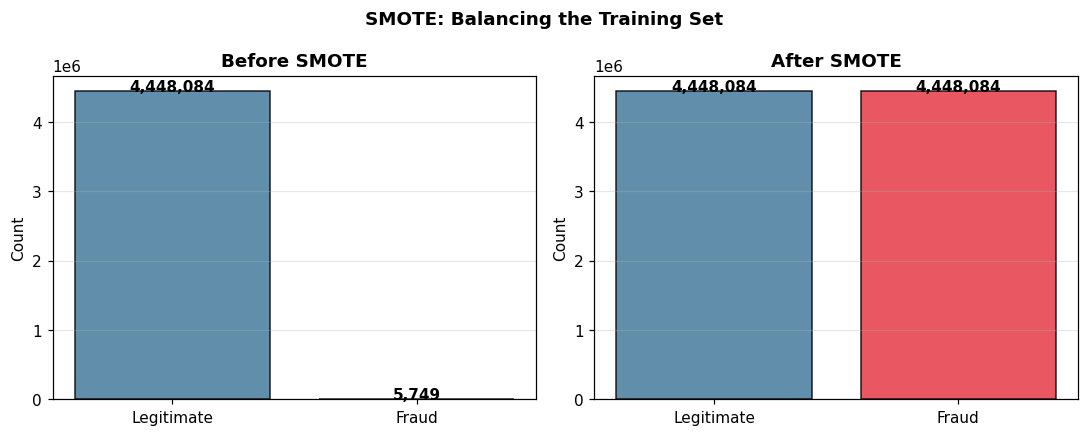

In [9]:
print('Strategy 1: Class Weights')
print('  Pass class_weight="balanced" to sklearn models.')
print('  Penalises misclassifying minority (fraud) class more heavily.')
print('  No data modification — computationally cheap.')
print()
print('Strategy 2: SMOTE (Synthetic Minority Oversampling)')
print('  Generates synthetic fraud samples by interpolating between')
print('  existing fraud examples in feature space.')
print('  Applied ONLY to training set — never val or test.')
print()

# Apply SMOTE to training set only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_s.values, y_train.values)

print(f'Before SMOTE: {Counter(y_train)}')
print(f'After  SMOTE: {Counter(y_train_smote)}')
print(f'Training set grew from {len(y_train):,} → {len(y_train_smote):,} rows')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [Counter(y_train), Counter(y_train_smote)],
    ['Before SMOTE', 'After SMOTE']):
    ax.bar(['Legitimate', 'Fraud'], [counts[0], counts[1]],
           color=[LEGIT_COLOR, FRAUD_COLOR], alpha=0.85, edgecolor='k')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.suptitle('SMOTE: Balancing the Training Set', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9: Final Data Summary

In [10]:
print('='*60)
print('  PREPROCESSING COMPLETE – FINAL SUMMARY')
print('='*60)
print()
print('Datasets ready for modeling:')
print(f'  X_train_s      : {X_train_s.shape}   (scaled, no SMOTE)')
print(f'  X_train_smote  : {X_train_smote.shape}  (scaled + SMOTE)')
print(f'  y_train        : {y_train.shape}')
print(f'  y_train_smote  : {y_train_smote.shape}')
print(f'  X_val_s        : {X_val_s.shape}')
print(f'  X_test_s       : {X_test_s.shape}')
print()
print('Steps completed:')
steps = [
    'Dropped leakage columns (isFlaggedFraud, nameOrig, nameDest)',
    'Verified no missing values',
    'Engineered 9 new features (log_amount, balance deltas, flags)',
    'One-hot encoded transaction type',
    '70/15/15 stratified train/val/test split',
    'StandardScaler fit on train only — no leakage',
    'SMOTE applied to training set only',
]
for i, s in enumerate(steps, 1):
    print(f'  {i}. {s}')
print()
print('Ready for: Logistic Regression, Naive Bayes, kNN,')
print('           Decision Tree, Random Forest, XGBoost,')
print('           Linear SVM, RBF SVM')

  PREPROCESSING COMPLETE – FINAL SUMMARY

Datasets ready for modeling:
  X_train_s      : (4453833, 19)   (scaled, no SMOTE)
  X_train_smote  : (8896168, 19)  (scaled + SMOTE)
  y_train        : (4453833,)
  y_train_smote  : (8896168,)
  X_val_s        : (954394, 19)
  X_test_s       : (954393, 19)

Steps completed:
  1. Dropped leakage columns (isFlaggedFraud, nameOrig, nameDest)
  2. Verified no missing values
  3. Engineered 9 new features (log_amount, balance deltas, flags)
  4. One-hot encoded transaction type
  5. 70/15/15 stratified train/val/test split
  6. StandardScaler fit on train only — no leakage
  7. SMOTE applied to training set only

Ready for: Logistic Regression, Naive Bayes, kNN,
           Decision Tree, Random Forest, XGBoost,
           Linear SVM, RBF SVM


In [11]:
pip install -U imbalanced-learn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install imbalanced-learn==0.12.0

  Using cached imbalanced_learn-0.12.0-py3-none-any.whl.metadata (8.2 kB)
Using cached imbalanced_learn-0.12.0-py3-none-any.whl (257 kB)
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.1
    Uninstalling imbalanced-learn-0.14.1:
      Successfully uninstalled imbalanced-learn-0.14.1
Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install -U scikit-learn imbalanced-learn --force-reinstall

  Using cached scikit_learn-1.8.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-macosx_12_0_arm64.whl (8.1 MB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl (20.3 MB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Attempting uninstall: threadpoolct